# Framing Results — by Topic Cluster

Joins the GPT-5.4-mini frame classifications (from [`../02_Framing_Classification_Run/02_Classification_Run_GPT.ipynb`](../02_Framing_Classification_Run/02_Classification_Run_GPT.ipynb)) back to the 18 manual topic clusters from Mechanism 1. Produces the topic-cluster × outlet heatmaps of the **delegitimization rate** (share of mentions in any of the four bias frames) and the frame-category breakdowns used in the thesis.

In [ ]:
import pandas as pd

OUTLET_RENAME = {
    "RT_de":           "RT DE",
    "Tichys_Einblick": "Tichys Einblick",
    "Nius":            "NIUS",
}

df = pd.read_csv("media_framing_final_run_5_4mini_classifications.csv")
df["source"] = df["source"].replace(OUTLET_RENAME)

print("Sources in df:", sorted(df["source"].unique()))

Sources in df: ['Antispiegel', 'Compact', 'Deutschlandkurier', 'NIUS', 'RT DE', 'Tagesschau', 'Tichys Einblick']


In [ ]:
topics = pd.read_csv(
    "03_new_topic_assignments.csv",
    usecols=["row_id", "source", "Manual Topic Label", "Manual Cluster Label"],
)

# Normalize source names to match the framing CSV
topics["source"] = topics["source"].replace({
    "RT":              "RT DE",
    "RT_de":           "RT DE",
    "Tichys_Einblick": "Tichys Einblick",
    "Nius":            "NIUS",
})

df = df.merge(topics, on=["row_id", "source"], how="left")

print(f"Rows: {len(df)}")
print(f"Manual Topic Label   — filled: {df['Manual Topic Label'].notna().sum()}  |  missing: {df['Manual Topic Label'].isna().sum()}")
print(f"Manual Cluster Label — filled: {df['Manual Cluster Label'].notna().sum()}  |  missing: {df['Manual Cluster Label'].isna().sum()}")


Rows: 11975
Manual Topic Label   — filled: 11583  |  missing: 392
Manual Cluster Label — filled: 11583  |  missing: 392


In [7]:
df['source'].value_counts()

source
Tagesschau           4370
Tichys Einblick      2282
NIUS                 2026
RT DE                1864
Antispiegel           540
Compact               512
Deutschlandkurier     381
Name: count, dtype: int64

## Filter data (exclude IRRELEVANT & Tagesschau)

In [8]:
df = df[df['category'] != 'IRRELEVANT']
df = df[df['source']   != 'Tagesschau']

print(f"Rows after filtering: {len(df)}")
print(f"Sources remaining: {sorted(df['source'].unique())}")

Rows after filtering: 7339
Sources remaining: ['Antispiegel', 'Compact', 'Deutschlandkurier', 'NIUS', 'RT DE', 'Tichys Einblick']


## Topic Level Analysis

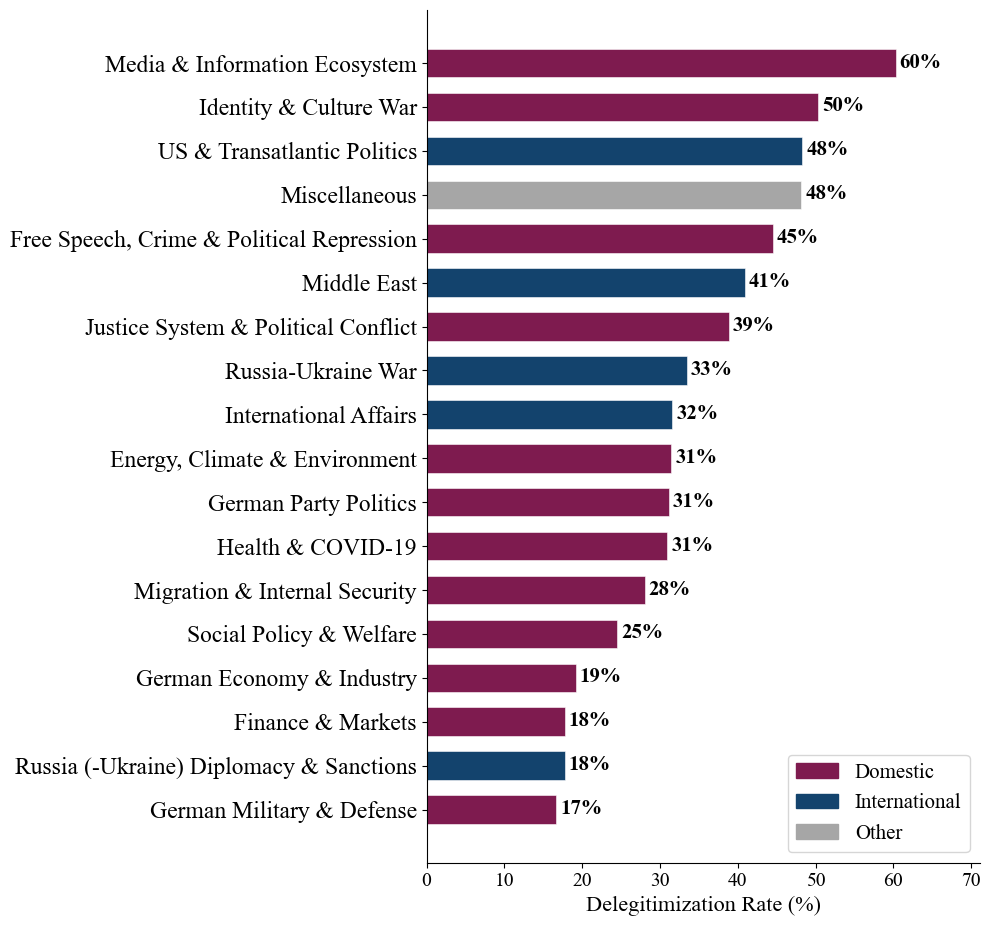

In [9]:
# ── Delegitimization rate per topic cluster, coloured by geography ───────────
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["font.family"] = "Times New Roman"

DOMESTIC = {
    "Social Policy & Welfare", "Health & COVID-19", "Energy, Climate & Environment",
    "German Economy & Industry", "Migration & Internal Security", "German Party Politics",
    "Free Speech, Crime & Political Repression", "Media & Information Ecosystem",
    "Justice System & Political Conflict", "Identity & Culture War",
    "Finance & Markets", "German Military & Defense",
}
INTERNATIONAL = {
    "Middle East", "Russia (-Ukraine) Diplomacy & Sanctions",
    "US & Transatlantic Politics", "Russia-Ukraine War", "International Affairs",
}
GEO_COLOR = {"Domestic": "#7e1b4f", "International": "#13436d", "Other": "#a6a6a6"}

def _geo(c):
    return "Domestic" if c in DOMESTIC else "International" if c in INTERNATIONAL else "Other"

df_known = df.dropna(subset=["Manual Cluster Label"]).copy()
df_known["Manual Cluster Label"] = df_known["Manual Cluster Label"].str.rstrip("#").str.strip()

total_c   = df_known.groupby("Manual Cluster Label").size()
framing_c = df_known[df_known["category"] != "NEUTRAL"].groupby("Manual Cluster Label").size()
deleg     = ((framing_c / total_c) * 100).dropna().sort_values(ascending=True)
colors    = [GEO_COLOR[_geo(c)] for c in deleg.index]

fig, ax = plt.subplots(figsize=(10, max(6, len(deleg) * 0.52)))
bars = ax.barh(deleg.index, deleg.values, color=colors, edgecolor="white", linewidth=0.4, height=0.65)

for bar, val in zip(bars, deleg.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}%", va="center", fontsize=15, fontweight="bold")

ax.set_xlabel("Delegitimization Rate (%)", fontsize=16)
ax.set_ylabel("")
ax.set_xlim(0, deleg.max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.grid(False)
ax.tick_params(axis="y", labelsize=17)
ax.tick_params(axis="x", labelsize=14)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=v, label=k) for k, v in GEO_COLOR.items()],
          loc="lower right", fontsize=15, frameon=True)
plt.tight_layout()
plt.show()


In [10]:
# ── Average delegitimisation rate: domestic vs international per outlet ───────
# Reuses df_known, _geo(), from cell above

df_known["geo"] = df_known["Manual Cluster Label"].map(_geo)

results = []
for outlet, grp in df_known[df_known["source"] != "Tagesschau"].groupby("source"):
    for geo in ("Domestic", "International"):
        sub     = grp[grp["geo"] == geo]
        total   = len(sub)
        if total == 0:
            continue
        framing = (sub["category"] != "NEUTRAL").sum()
        results.append({
            "Outlet": outlet,
            "Geography": geo,
            "Delegitimisation rate": framing / total * 100,
            "n": total,
        })

summary = (
    pd.DataFrame(results)
    .pivot(index="Outlet", columns="Geography", values="Delegitimisation rate")
    .round(1)
)
summary.columns.name = None
summary["Δ (Dom − Intl)"] = (summary["Domestic"] - summary["International"]).round(1)
summary = summary.sort_values("Domestic", ascending=False)
print(summary.to_string())


                   Domestic  International  Δ (Dom − Intl)
Outlet                                                    
Antispiegel            72.4           48.5            23.9
Tichys Einblick        48.6           52.8            -4.2
Compact                35.9           38.7            -2.8
NIUS                   33.5           58.5           -25.0
Deutschlandkurier      32.6           19.6            13.0
RT DE                  22.4           13.8             8.6


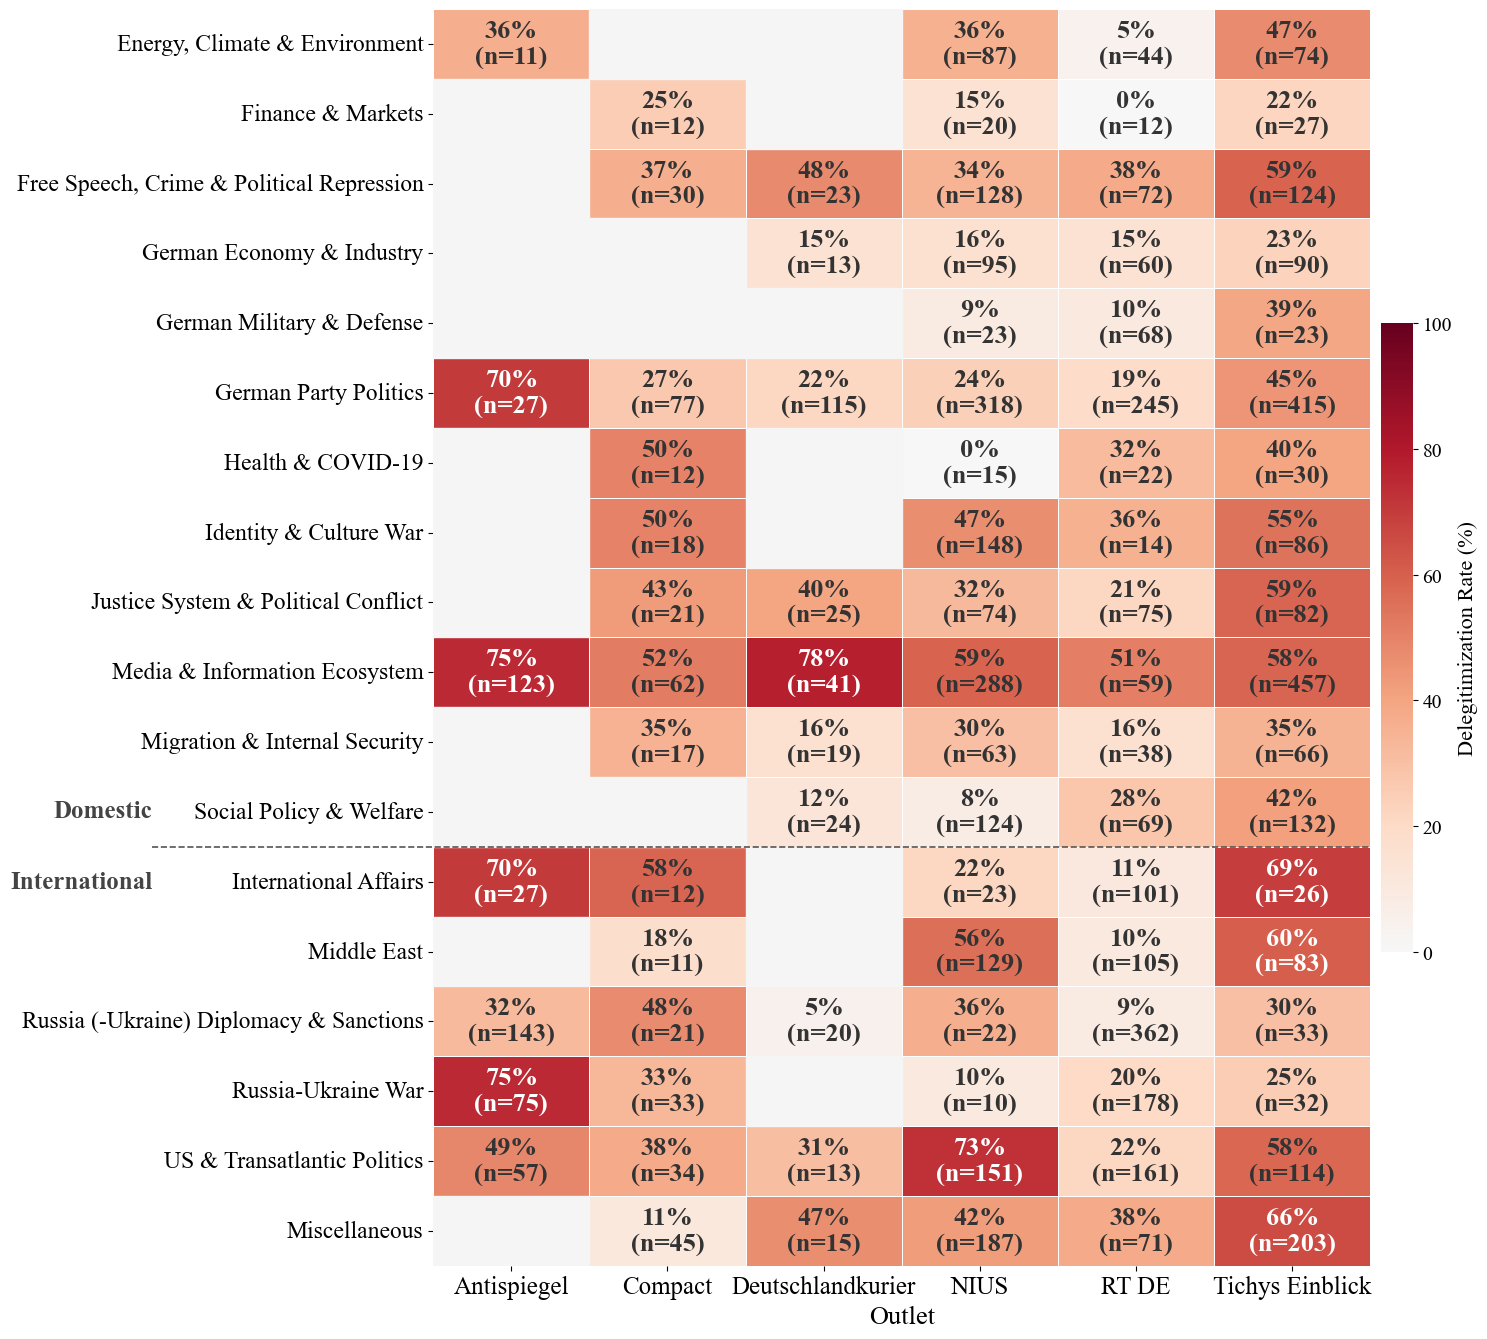

In [11]:
# ── Heatmap: delegitimization rate per topic cluster × outlet ────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import numpy as np
import matplotlib as mpl
mpl.rcParams["font.family"] = "Times New Roman"

MIN_N = 10

THESIS_SEQ = LinearSegmentedColormap.from_list(
    "thesis_seq", ["#f7f7f7", "#fddbc7", "#f4a582", "#d6604d", "#b2182b", "#67001f"], N=256
)

df_known = df.dropna(subset=["Manual Cluster Label"]).copy()
df_known["Manual Cluster Label"] = df_known["Manual Cluster Label"].str.rstrip("#").str.strip()

total_g = (
    df_known.groupby(["Manual Cluster Label", "source"]).size()
    .unstack(fill_value=0).astype(float)
)
framed_g = (
    df_known[df_known["category"] != "NEUTRAL"]
    .groupby(["Manual Cluster Label", "source"]).size()
    .unstack(fill_value=0)
    .reindex_like(total_g).fillna(0)
)
rate_raw = (framed_g / total_g.replace(0, np.nan)) * 100

def _geo_rank(cluster):
    if cluster in DOMESTIC:      return 0
    if cluster in INTERNATIONAL: return 1
    return 2

sorted_clusters = sorted(rate_raw.index.tolist(), key=_geo_rank)
rate_vis  = rate_raw.reindex(sorted_clusters)
total_vis = total_g.reindex(sorted_clusters)
rate_plot = rate_vis.where(total_vis >= MIN_N)

all_outlets = rate_plot.columns.tolist()

def _add_geo_brackets(ax, clusters_ordered):
    last_dom, first_intl = None, None
    for i, c in enumerate(clusters_ordered):
        if c in DOMESTIC:      last_dom = i
        elif c in INTERNATIONAL and first_intl is None: first_intl = i
    if last_dom is None or first_intl is None: return
    sep_y = first_intl
    ax.plot([-0.30, 1.0], [sep_y, sep_y], color="#555555", linewidth=1.2,
            linestyle="--", zorder=4, transform=ax.get_yaxis_transform(), clip_on=False)
    ax.text(-0.30, sep_y - 0.35, "Domestic", ha="right", va="bottom",
            fontsize=18, color="#444444", fontweight="bold",
            transform=ax.get_yaxis_transform(), clip_on=False)
    ax.text(-0.30, sep_y + 0.35, "International", ha="right", va="top",
            fontsize=18, color="#444444", fontweight="bold",
            transform=ax.get_yaxis_transform(), clip_on=False)

fig, ax = plt.subplots(figsize=(max(16, 2.6 * len(all_outlets)),
                                max(11, 0.75 * len(sorted_clusters))))

sns.heatmap(rate_plot, ax=ax, annot=False,
            cmap=THESIS_SEQ, vmin=0, vmax=100,
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Delegitimization Rate (%)", "shrink": 0.5, "pad": 0.01})

ax.figure.axes[-1].yaxis.label.set_size(16)
ax.figure.axes[-1].tick_params(labelsize=14)

for ri, cluster in enumerate(sorted_clusters):
    for ci, outlet in enumerate(all_outlets):
        val = rate_plot.at[cluster, outlet]
        n   = total_vis.at[cluster, outlet]
        if np.isnan(val):
            ax.add_patch(plt.Rectangle((ci, ri), 1, 1, color="#f5f5f5", zorder=2))
        else:
            ax.text(ci + 0.5, ri + 0.5, f"{val:.0f}%\n(n={int(n)})",
                    ha="center", va="center", fontsize=19, fontweight="bold",
                    color="white" if val > 60 else "#333333", zorder=3)

ax.set_xlabel("Outlet", fontsize=19)
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=18)
ax.tick_params(axis="y", labelsize=17)
_add_geo_brackets(ax, sorted_clusters)
plt.tight_layout()
plt.show()
